## Notebook 12 – Feature Relationships

### Setup
This notebook needs a few extra libraries: `statsmodels` (for VIF), `scikit-learn` (for Random Forest and SelectKBest) and `seaborn` (for the heatmap). 

In [7]:
!pip install statsmodels scikit-learn seaborn

In [9]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\rafiy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\rafiy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression

# keeping all charts at a similar size so they look consistent
plt.rcParams["figure.figsize"] = (6, 4)

### Sample Dataset
Instead of making a new small table for every topic, I created one house price dataset with 200 houses and I will reuse it for all 5 topics below. The features are `sqft`, `rooms`, `bathrooms`, `age` and `distance_to_city`, and the target is `price`.

I made `rooms` depend closely on `sqft` (bigger houses have more rooms) on purpose, so that there is a real multicollinearity problem to detect. The data is generated with a fixed seed, so it gives the same values every time.

In [18]:
np.random.seed(42)
n = 200

sqft = np.random.normal(2000, 500, n).clip(600, 4000).round(0)
rooms = (sqft / 400 + np.random.normal(0, 0.4, n)).clip(1, 12).round(0)
bathrooms = (sqft / 900 + np.random.normal(0, 0.6, n)).clip(1, 6).round(0)
age = np.random.randint(1, 40, n)
distance_to_city = np.random.uniform(1, 25, n).round(1)

# price mainly depends on sqft, a little on distance and age, plus random noise
price = (50 + 0.12 * sqft - 1.5 * distance_to_city - 0.4 * age + np.random.normal(0, 25, n)).round(1)

df = pd.DataFrame({
    "sqft": sqft,
    "rooms": rooms,
    "bathrooms": bathrooms,
    "age": age,
    "distance_to_city": distance_to_city,
    "price": price
})

df.head()

,sqft,rooms,bathrooms,age,distance_to_city,price
0,2248.0,6.0,2.0,4,10.7,315.7
1,1931.0,5.0,2.0,12,12.9,308.0
2,2324.0,6.0,3.0,2,18.3,310.9
3,2762.0,7.0,3.0,27,3.6,381.2
4,1883.0,4.0,2.0,31,4.4,284.5


**What this does:** It creates 200 houses. `rooms` and `bathrooms` are calculated from `sqft` plus some random noise, so they move with house size. `age` and `distance_to_city` are random. `price` is built mostly from `sqft`, with a small effect from distance and age, so the dataset has a clear and known structure to explore.

## Correlation Matrix

### Concept
A correlation matrix shows the correlation between every pair of columns in a dataset at once. It was already covered in detail in Notebook 8. Here it is used from a feature relationship point of view, to see which features are related to the target (price) and which features are related to each other.

### Example
In the house dataset, I expect `sqft` to be strongly related to `price`, and I also expect `sqft` and `rooms` to be strongly related to each other, since bigger houses have more rooms. The correlation matrix is the quickest way to check both.

### Python Implementation

                  sqft  rooms  bathrooms   age  distance_to_city  price
sqft              1.00   0.92       0.50 -0.00             -0.03   0.89
rooms             0.92   1.00       0.44 -0.03             -0.05   0.81
bathrooms         0.50   0.44       1.00 -0.02              0.06   0.43
age              -0.00  -0.03      -0.02  1.00              0.05  -0.08
distance_to_city -0.03  -0.05       0.06  0.05              1.00  -0.20
price             0.89   0.81       0.43 -0.08             -0.20   1.00


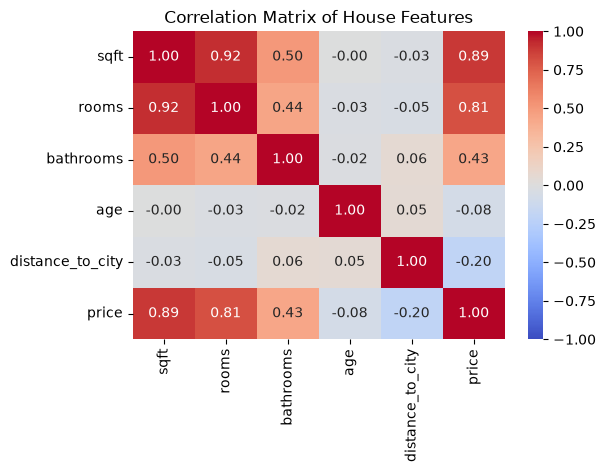

In [20]:
corr = df.corr()
print(corr.round(2))

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix of House Features")
plt.show()

#### What the program does
The program calculates the correlation between every pair of columns, prints it as a table, and then draws the same table as a colored heatmap with the values written inside each cell.

#### Why the graph looks like this
The `sqft` row and the `price` column are dark red (about 0.89), because price was built mostly from square footage. `sqft` and `rooms` are also dark red (about 0.92), which is the warning sign for multicollinearity. `age` is almost white against everything, because it was generated randomly and has no real relationship with the other columns. `distance_to_city` has a small negative value with price (about -0.20), since farther houses are slightly cheaper.

#### Advantages
- Shows every pairwise relationship in one place, including the relationship with the target.

#### Limitations
- Only shows relationships between two columns at a time and only linear ones.

#### Key Point
A Correlation Matrix is the quickest first look at how features relate to each other and to the target, before deciding which features to keep or investigate further.

#### Note
This overlaps with Notebook 8, so I kept it short and focused on features and multicollinearity. The next topic builds directly on it.

## Multicollinearity

### Concept
Multicollinearity happens when two or more input features are highly correlated with each other. It is a problem mainly for models like Linear Regression, because when two features carry almost the same information, the model cannot tell which one is really responsible for the change in the target. This makes the coefficients unstable and hard to interpret.

### Example
In the house dataset, `sqft` and `rooms` are an example. If both are used to predict price, they are basically competing to explain the same thing, since a house with more square feet almost always has more rooms.

### Python Implementation

Correlation between sqft and rooms: 0.918
These two features are highly correlated, multicollinearity is a concern.


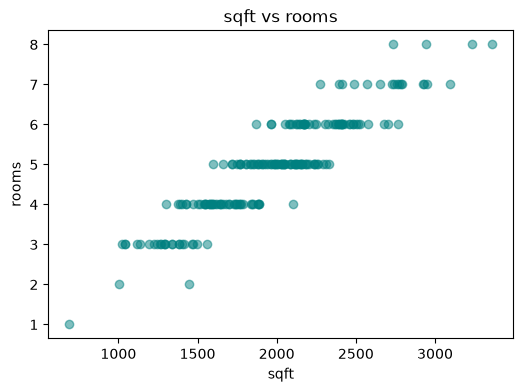

In [21]:
features = ["sqft", "rooms", "bathrooms", "age", "distance_to_city"]

correlation_between_features = df["sqft"].corr(df["rooms"])
print("Correlation between sqft and rooms:", round(correlation_between_features, 3))

if abs(correlation_between_features) > 0.8:
    print("These two features are highly correlated, multicollinearity is a concern.")

plt.scatter(df["sqft"], df["rooms"], alpha=0.5, color="teal")
plt.title("sqft vs rooms")
plt.xlabel("sqft")
plt.ylabel("rooms")
plt.show()

#### What the program does
The program checks the correlation specifically between two input features (not the target) and prints a warning if it is above 0.8. It then plots those two features against each other.

#### Why the graph looks like this
The points form a tight band going from bottom left to top right, almost like a line. This is because `rooms` was calculated from `sqft` plus a small amount of noise, so for a given house size the number of rooms barely changes. A band this tight is exactly what multicollinearity looks like visually: knowing one feature almost tells you the other.

#### Advantages
- Detecting it is easy with a correlation check.

#### Limitations
- Fixing it needs a decision about which feature to drop or combine, and that is not always obvious.

#### Key Point
Multicollinearity means two or more input features are so highly correlated that they are basically redundant, which makes some models' results unreliable.

## Variance Inflation Factor (VIF)

### Concept
VIF puts an actual number on how much multicollinearity there is for each feature. It measures how much the variance of a feature's coefficient is inflated because the feature is correlated with the other features. A VIF of 1 means no correlation with the other features, and a value above 5 (or 10, depending on how strict you are) is usually treated as a warning sign.

### Example
If a feature has a high VIF, it means it can be predicted well from the other features, so it is mostly redundant. Removing it would barely change what the model can learn.

### Python Implementation

In [22]:
X = add_constant(df.drop(columns="price"))

vif_data = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

# the constant is only needed for the calculation, so I am removing it from the result
vif_data = vif_data[vif_data["feature"] != "const"]
print(vif_data.round(2))

            feature   VIF
1              sqft  6.92
2             rooms  6.44
3         bathrooms  1.36
4               age  1.01
5  distance_to_city  1.01


#### What the program does
The program takes only the input features (price is dropped since it is the target) and adds a constant column, which is needed for VIF to be calculated correctly. For each feature, VIF checks how well that feature can be predicted from all the others, and the result is shown in a small table.

#### Advantages
- Gives a clear number for multicollinearity per feature, instead of just guessing from a correlation matrix.
- Captures a feature being predicted by several other features together, which a pairwise matrix can miss.

#### Limitations
- Only captures linear relationships, and the cutoff of 5 or 10 is a rule of thumb, not a strict law.

#### Key Point
VIF puts a number on multicollinearity for each feature, with values above 5 to 10 usually signaling a feature that is largely redundant.

#### Note
`sqft` and `rooms` should come out with the highest VIF values (around 6 to 7), which is above the cutoff of 5, while `bathrooms`, `age` and `distance_to_city` should be close to 1. I checked the same calculation separately and got about 6.9 for `sqft` and 6.4 for `rooms`. The exact decimals may differ slightly, but the pattern should be the same: the two features that move together are flagged and the independent ones are not.

## Feature Importance

### Concept
Feature Importance tells us how much each feature contributes to a model's predictions. Some models, like Random Forest, can calculate this directly and rank the features from most to least useful for predicting the target.

### Example
In the house price model, I expect `sqft` to be the most important feature, because price was built mostly from it.

### Python Implementation

rooms               0.009
bathrooms           0.014
age                 0.042
distance_to_city    0.078
sqft                0.856
dtype: float64


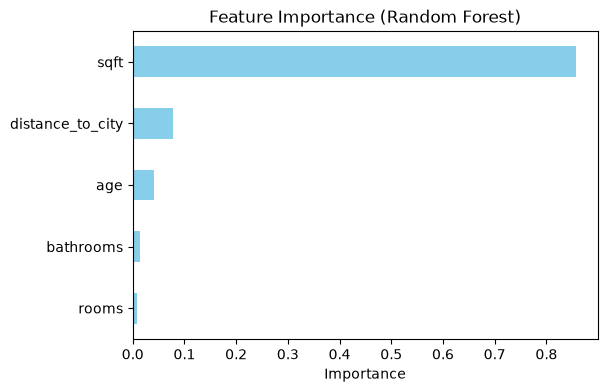

In [23]:
X = df.drop(columns="price")
y = df["price"]

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns).sort_values()
print(importance.round(3))

importance.plot(kind="barh", color="skyblue")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

#### What the program does
The program trains a Random Forest to predict price from all five features, then reads `feature_importances_`, which says how much each feature helped the model make its splits. The values are sorted and shown as a horizontal bar chart.

#### Why the graph looks like this
The `sqft` bar is by far the longest (around 0.86), because price depends mostly on square footage. `distance_to_city` and `age` have small bars, which matches their small real effect on price. The surprising part is that `rooms` has almost no importance, even though it has a correlation of about 0.81 with price. This happens because `rooms` is nearly a copy of `sqft`, so once the model uses `sqft`, `rooms` adds almost nothing new and the credit goes to `sqft`.

#### Advantages
- Helps focus on the features that matter most to a model's predictions.

#### Limitations
- When features are correlated, tree models split the importance unevenly between them, so a useful but redundant feature (like `rooms`) can look unimportant.

#### Key Point
Feature Importance ranks features by how much they influence a model's predictions, but it should be read together with multicollinearity checks.

#### Note
`sqft` should come out on top by a large margin. I ran this with `random_state=42` and `sqft` was about 0.86, followed by `distance_to_city` at about 0.08. Importance values can change slightly with a different random state or dataset.

## Feature Selection Basics

### Concept
Feature Selection is the process of picking only the most useful features for a model and dropping the ones that are redundant or irrelevant. It usually makes models simpler, faster to train and less likely to overfit. It combines everything from this notebook: correlation, multicollinearity, VIF and feature importance.

### Example
If a dataset has many features but only a few of them really matter for the target, feature selection is about keeping those and dropping the rest, instead of giving everything to the model.

### Python Implementation

In [24]:
X = df.drop(columns="price")
y = df["price"]

selector = SelectKBest(score_func=f_regression, k=3)
selector.fit(X, y)

scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
print("Feature scores:")
print(scores.round(1))

selected_features = list(X.columns[selector.get_support()])
print("Selected top 3 features:", selected_features)

Feature scores:
sqft                742.6
rooms               375.0
bathrooms            46.0
distance_to_city      8.4
age                   1.2
dtype: float64
Selected top 3 features: ['sqft', 'rooms', 'bathrooms']


#### What the program does
The program uses `SelectKBest` to give every feature a score based on how strongly it is related to the target (using an F-test), and keeps the top 3 features. The scores are printed so we can see why each feature was kept or dropped.

#### Advantages
- Gives simpler models that train faster and are easier to explain.
- Reduces the risk of overfitting by removing noisy or irrelevant features.

#### Limitations
- `SelectKBest` scores each feature on its own, so it ignores redundancy. A feature can be kept even when it adds nothing new.

#### Key Point
Feature Selection keeps only the features that genuinely help the model, but the choice should combine statistical scores with checks like VIF.

#### Note
`SelectKBest` keeps `sqft`, `rooms` and `bathrooms`. It keeps `rooms` because `rooms` is strongly related to price on its own, even though VIF and Feature Importance showed it is redundant with `sqft`. So in a real project, I would not trust this result alone. I would drop `rooms` because of its high VIF, and probably keep `distance_to_city` since it has a real effect on price even though its score is lower. This is a good example of why one method is not enough.

## Interview Questions

**1. What is multicollinearity and why is it a problem?**</br>
Multicollinearity is when two or more input features are highly correlated with each other. It is a problem for models like Linear Regression because the model cannot tell which correlated feature is responsible for the effect on the target, which makes the coefficients unstable and hard to interpret.

**2. What does VIF measure and what value is considered problematic?**</br>
VIF measures how much a feature's variance is inflated because of its correlation with the other features. A VIF of 1 means no correlation with other features, while values above 5 or 10 are usually considered a sign of problematic multicollinearity.

**3. How is a Correlation Matrix different from VIF for detecting multicollinearity?**</br>
A correlation matrix only shows pairwise relationships between two features at a time. VIF captures how well one feature can be predicted by all the other features together, so it can catch multicollinearity that a pairwise matrix might miss.

**4. What is Feature Importance and how is it calculated in a Random Forest?**</br>
Feature Importance measures how much each feature contributes to a model's predictions. In a Random Forest, it is typically calculated from how much each feature reduces impurity (or error) across all the trees when it is used to make a split.

**5. Why can a useful feature show very low importance in a Random Forest?**</br>
If it is highly correlated with another feature, the model can use either one, and the credit often goes mostly to one of them. In this notebook, `rooms` is strongly related to price but shows almost no importance, because `sqft` already carries the same information.

**6. Why do we perform Feature Selection?**</br>
To keep only the features that genuinely help the model, which makes it simpler, faster to train, easier to interpret and less likely to overfit to noise from irrelevant features.